In [1]:
import jax.numpy as jnp
import jax
import numpy as np

from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
jax.default_backend()

'gpu'

In [3]:
np.random.seed(2)

In [4]:
def generate_gaussian_feature_matrix(n, k, theta):
    return (1 / np.sqrt(n+theta)) * jnp.asarray(np.random.randn(k, n))

In [5]:
def data_generator(xi, gamma, m, n, theta, delta):
    A = jnp.asarray(np.random.randn(m,n))
    c = jnp.asarray(np.random.randn(m,1))
    X = np.sqrt(theta)*c*gamma.reshape(1,n) + A
    epsilon = jnp.asarray(np.random.randn(m,1))
    alpha = (xi.T @ gamma).item()
    y = jnp.maximum((1/np.sqrt(1+theta*(alpha**2))) * X @ xi,0) + delta * epsilon
    return X,y

In [6]:
def loss(w, y, b, RF, l, lambd):
    return jnp.mean(l(y, RF.T@w + b)) + lambd * (jnp.linalg.norm(w) ** 2)

In [7]:
def l(y, z):
    return (y-z)**2

In [8]:
def least_square_estimator(y, b, RF, lambd):
    k, m = RF.shape
    w = jnp.linalg.inv(RF @ RF.T + lambd * m * jnp.eye(k)) @ RF @ (y - b)
    return w

In [9]:
def ReLU(z):
    return jnp.maximum(z,0)

def ReLU_grad(z):
    return jnp.where(z > 0, 1, 0)

def Softplus(z):
    return jnp.log(1+jnp.exp(z))

def Softplus_grad(z):
    return 1 / (1 + jnp.exp(-z))

In [10]:
rho = 1
n = 400
k = 500
m = 500
lambd = 1e-2
delta = 0
theta = np.sqrt(n)
NB_TRIALS = 50

In [11]:
xi = np.random.randn(n, 1)
xi *= rho / np.linalg.norm(xi)

In [12]:
z = np.random.randn(100000)
rmu0 = ReLU(z).mean()
rmu1 = (z * ReLU(z)).mean()
rmus = np.sqrt((ReLU(z) ** 2).mean() - rmu0**2 - rmu1**2)
smu0 = Softplus(z).mean()
smu1 = (z * Softplus(z)).mean()
smus = np.sqrt((Softplus(z) ** 2).mean() - smu0**2 - smu1**2)

In [13]:
import gc,sys

def clear_caches():
    for module_name, module in sys.modules.items():
        if module_name.startswith("jax"):
            if module_name not in ["jax.interpreters.partial_eval"]:
                for obj_name in dir(module):
                    obj = getattr(module, obj_name)
                    if hasattr(obj, "cache_clear"):
                        try:
                            obj.cache_clear()
                        except:
                            pass
    gc.collect()

In [ ]:

alpha_vals = np.linspace(0,1,30)
logtheta_vals = np.linspace(-1,1,30)


relu_l_feature = np.zeros((len(alpha_vals), len(logtheta_vals), NB_TRIALS))
relu_gl_feature = np.zeros((len(alpha_vals), len(logtheta_vals), NB_TRIALS))
relu_l_gaussian = np.zeros((len(alpha_vals), len(logtheta_vals), NB_TRIALS))
relu_gl_gaussian = np.zeros((len(alpha_vals), len(logtheta_vals), NB_TRIALS))


def RFM(
    F,
    data,
    data_new,
    m,
    activation,
    mu0,
    mu1,
    mu2,
    lambd=lambd,
    include_gaussian=False,
):
    X, y = data
    X_new, y_new = data_new

    RF_feature = activation(F @ X.T)
    RF_feature_new = activation(F @ X_new.T)
    w_feature = least_square_estimator(y, 0, RF_feature, lambd)
    l_feature_ = loss(w_feature, y, 0, RF_feature, l, lambd)
    gl_feature_ = loss(w_feature, y_new, 0, RF_feature_new, l, 0)

    if include_gaussian:
        z = jnp.asarray(np.random.randn(k, m))
        z_new = jnp.asarray(np.random.randn(k, 5 * m))
        RF_gaussian = mu0 + mu1 * F @ X.T + mu2 * z
        RF_gaussian_new = mu0 + mu1 * F @ X_new.T + mu2 * z_new
        w_gaussian = least_square_estimator(y, 0, RF_gaussian, lambd)
        l_gaussian_ = loss(w_gaussian, y, 0, RF_gaussian, l, lambd)
        gl_gaussian_ = loss(w_gaussian, y_new, 0, RF_gaussian_new, l, 0)

        return (
            l_feature_.item(),
            gl_feature_.item(),
            l_gaussian_.item(),
            gl_gaussian_.item(),
        )
    else:
        return (l_feature_.item(), gl_feature_.item())


for e in tqdm(range(NB_TRIALS)):
    for a_i, alpha in enumerate(tqdm(alpha_vals)):
        r = np.random.randn(n, 1)
        gamma = alpha * xi + np.sqrt(1 - alpha**2) * (r / np.linalg.norm(r))
        for t_i, logtheta in enumerate(tqdm(logtheta_vals)):
            theta = np.power(n,logtheta)
            F = generate_gaussian_feature_matrix(n, k, theta)
            data = data_generator(xi, gamma, m, n, theta, delta)
            data_new = data_generator(xi, gamma, 5 * m, n, theta, delta)

            (
                relu_l_feature[a_i, t_i, e],
                relu_gl_feature[a_i, t_i, e],
                relu_l_gaussian[a_i, t_i, e],
                relu_gl_gaussian[a_i, t_i, e],
            ) = RFM(
                F,
                data,
                data_new,
                m,
                ReLU,
                rmu0,
                rmu1,
                rmus,
                lambd=lambd,
                include_gaussian=True,
            )

        clear_caches()

In [15]:
diff_relu_l_feature = np.abs(relu_l_gaussian - relu_l_feature) / relu_l_feature
diff_relu_gl_feature = np.abs(relu_gl_gaussian - relu_gl_feature) / relu_gl_feature

diff_relu_l_feature_mean = np.mean(diff_relu_l_feature, axis=2)
diff_relu_gl_feature_mean = np.mean(diff_relu_gl_feature, axis=2)

aa, tt = np.meshgrid(alpha_vals, np.power(k, logtheta_vals))

diff = np.zeros((len(aa), len(tt)))

for i in range(len(aa)):
    for j in range(len(tt)):
        diff[j, i] = diff_relu_gl_feature_mean[i, j]

In [ ]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

plt.style.use(["science", "bright"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 10,
        "figure.dpi": "600",
        "text.usetex": False
    }
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [21]:
diff_clip = np.clip(diff, 0, 1)

In [32]:
alpha = np.linspace(0, 1, 1000)
logtheta = np.linspace(0, 1, 1000)
theta = np.power(k, logtheta)

a, t = np.meshgrid(alpha, theta)

def f(a,t):
    return ((t*a)/np.sqrt(1+t*(a**2))) 

f_vals = f(a,t)
curve = theta[np.argmin(np.abs(f_vals - 2.5), axis=0)]

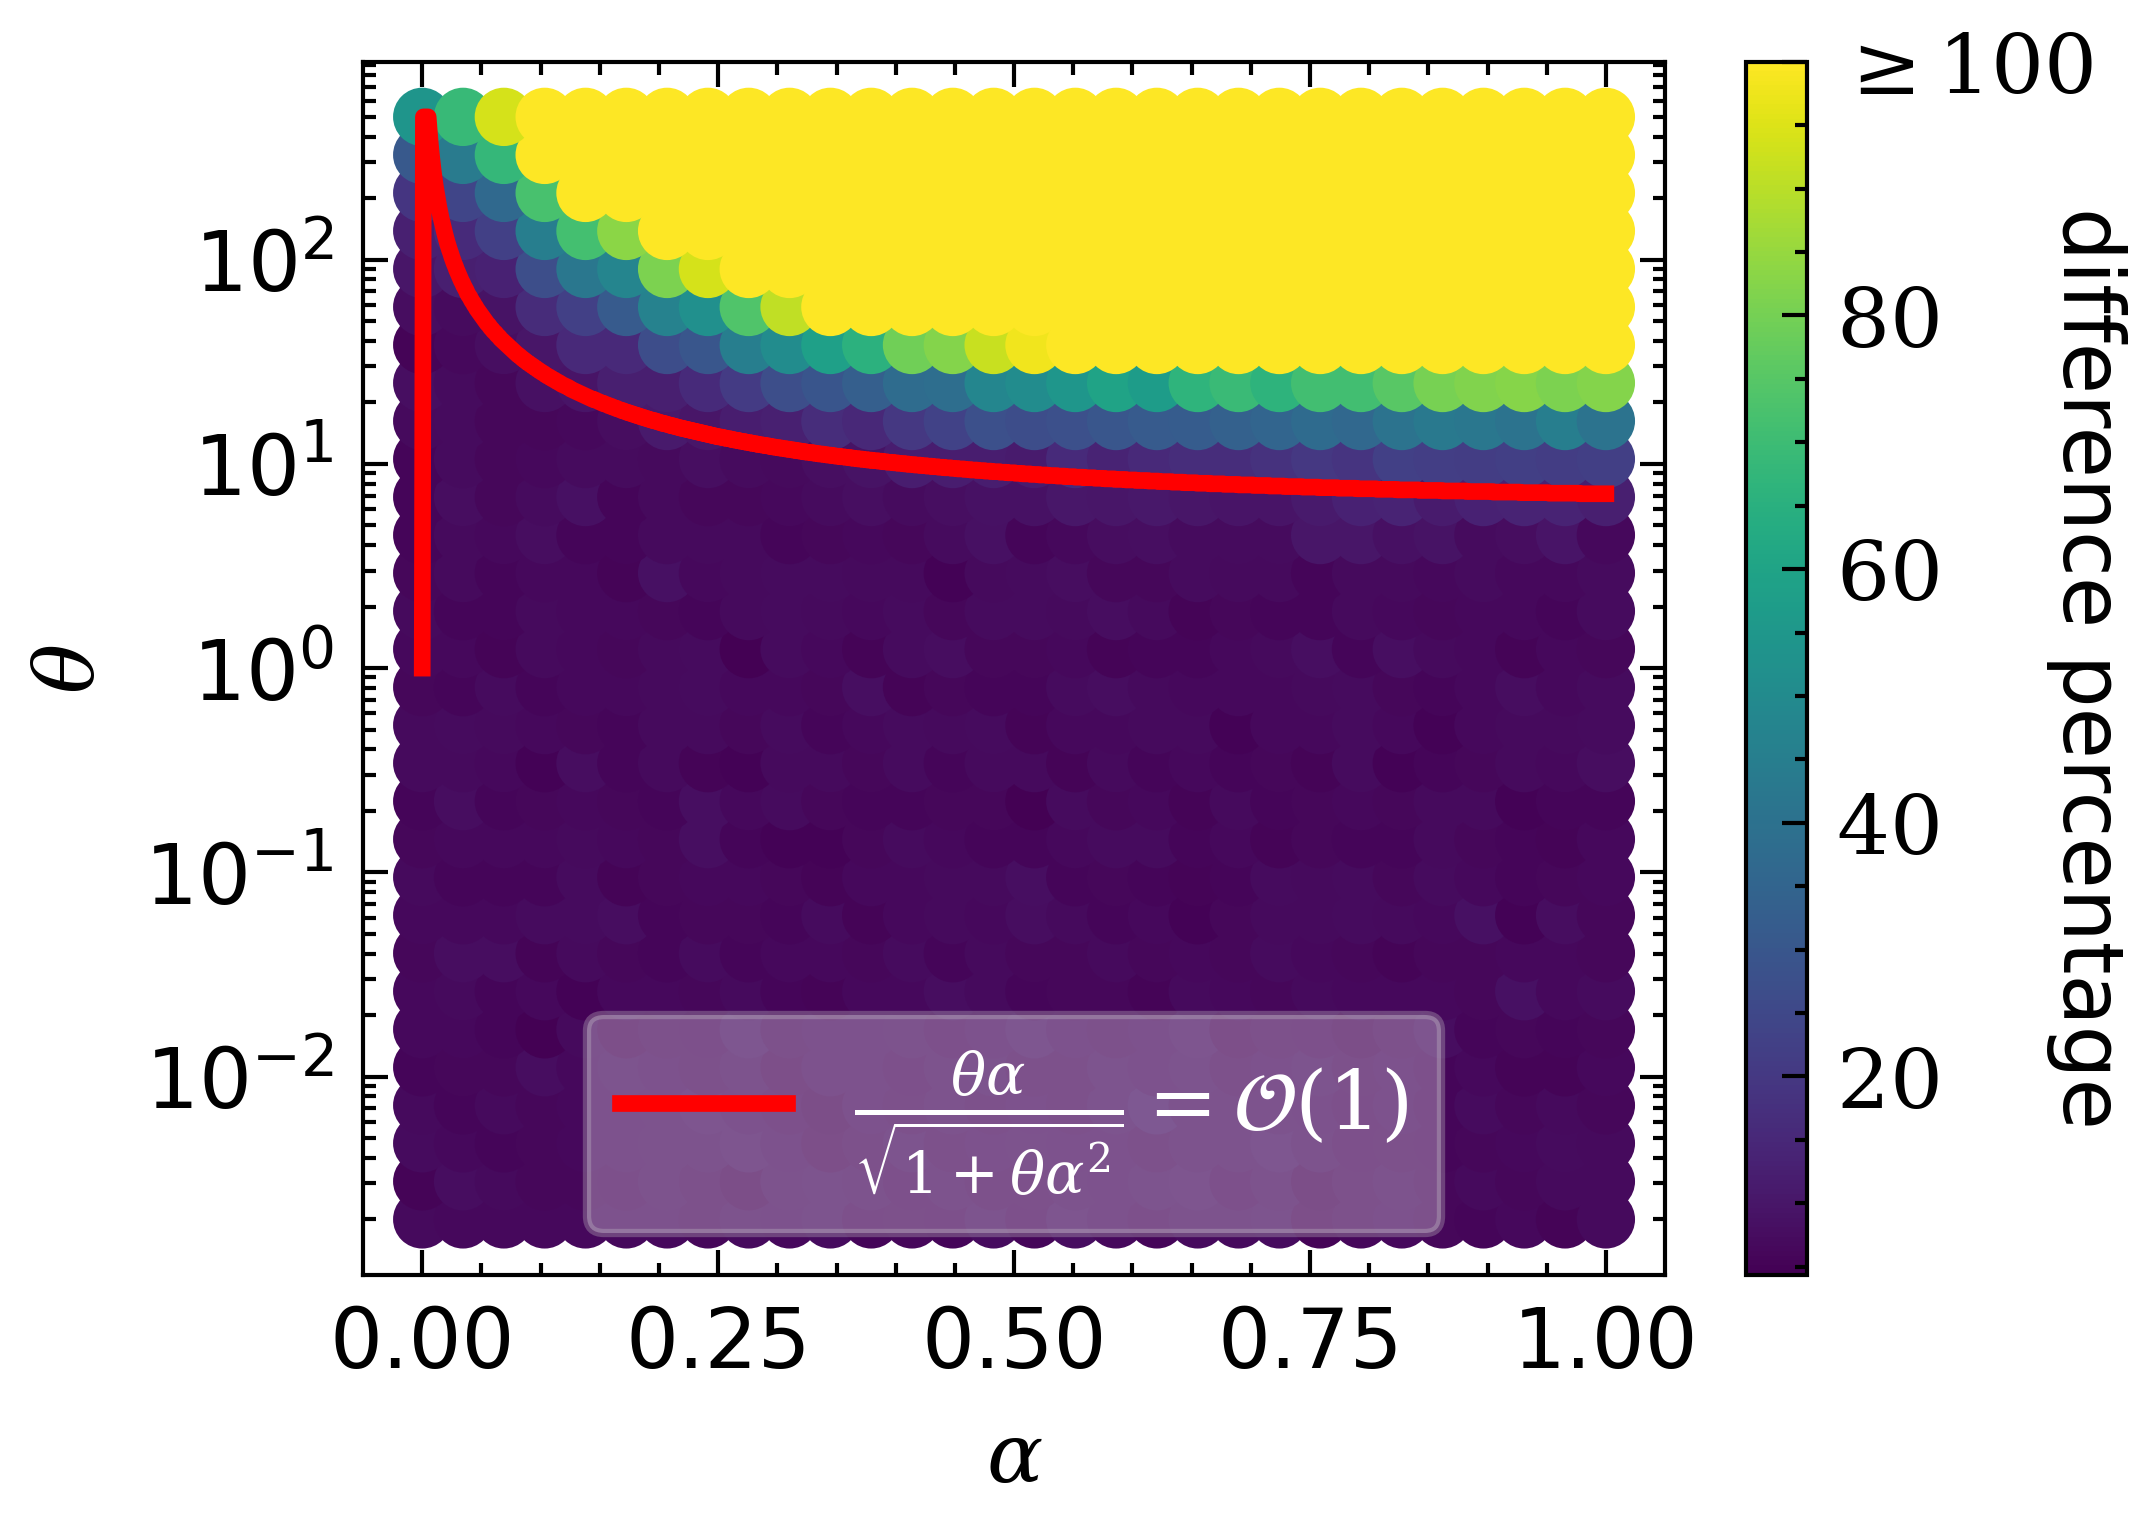

In [33]:
plt.figure()
plt.scatter(aa, tt, c=100 * diff_clip)
plt.yscale("log")
cbar = plt.colorbar(ticks=[20, 40, 60, 80, 100])
cbar.ax.set_yticklabels([r"$20$", r"$40$", r"$60$", r"$80$", r"$\geq 100$"])
cbar.set_label("difference percentage", rotation=270)
plt.xlabel(rf"$\alpha$")
plt.ylabel(rf"$\theta$")
plt.plot(
    alpha,
    curve,
    c="red",
    linewidth=2,
    linestyle="-",
    label=r"$\frac{\theta \alpha}{\sqrt{1+\theta\alpha^2}} = \mathcal{O}(1)$",
)
frame = plt.legend(loc="lower center", frameon=1, framealpha=0.3, labelcolor="white")